# Spider ML Task 1: Base Task

This notebook implements the given Fashion-MNIST neural network architecture in PyTorch. It includes a clean training pipeline with forward and backward propagation, epoch-wise training and validation loss/accuracy, Matplotlib plots, pickled model weights, and `submission.csv` test predictions.

Run this notebook in Google Colab. Upload the Kaggle Fashion-MNIST CSV files from `https://www.kaggle.com/datasets/zalando-research/fashionmnist`, especially `fashion-mnist_train.csv` and `fashion-mnist_test.csv`, into the Colab working directory before running all cells.

## Architecture used

The model follows the provided diagram:

- Input image: \(28 \times 28\)
- Flatten: \(784\)
- Shared hidden layer: \(784 \rightarrow 16\)
- Left branch: \(16 \rightarrow 8 \rightarrow 8\), followed by a skip/residual add
- Right branch: \(16 \rightarrow 12 \rightarrow 8\)
- Concatenate both 8-dimensional branch outputs into 16 features
- Output layer: \(16 \rightarrow 10\)

The output logits correspond to the 10 Fashion-MNIST classes.

In [1]:
# If running in a fresh Colab runtime, uncomment the next line if PyTorch is missing.
# !pip install torch --quiet

import os
import random
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Reproducibility and runtime configuration
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Training hyperparameters
BATCH_SIZE = 128
EPOCHS = 10 #these model params have been exp with. I have not provided the previous exp becuase it wasn't asked. 

LEARNING_RATE = 0.001 
WEIGHT_DECAY = 0.01 # Apparently simpler models are better, this tracks with the complexity of the task. Current params are an overkill. 
VALIDATION_RATIO = 0.15

# Use this only for a very quick smoke test. Keep False for final submission training.
RUN_FAST_DEMO = False # AI is pretty good at making these little tests, don't have to worry about much with them. 
FAST_DEMO_TRAIN_ROWS = 6000
FAST_DEMO_TEST_ROWS = 1000

Using device: cpu


In [3]:
def find_dataset_file(filename):
    # Find a Fashion-MNIST CSV file in common notebook/Colab/Kaggle paths.
    search_roots = [ # the file is in /content, but the code is too damn good to replace.
        Path("."),
        Path("/content"),
        Path("/content/data"),
        Path("/content/archive"),
        Path("/kaggle/input/fashionmnist"),
        Path("/kaggle/input/fashion-mnist"),
    ]
    for root in search_roots: # this seems like something that would be used in production tools to account for stupid devs who don't know their internal file struct becuase openClaw made it for them . 
        candidate = root / filename
        if candidate.exists():
            return candidate

    # Recursive fallback for Colab uploads/unzipped folders.
    for root in [Path("."), Path("/content"), Path("/kaggle/input")]:
        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                return matches[0]

    raise FileNotFoundError( #never had the chance to use the raise statement operator till now
        f"Could not find {filename}. Upload the Kaggle Fashion-MNIST CSV files "
        "to the notebook directory or /content, then rerun this cell."
    )


train_csv_path = find_dataset_file("fashion-mnist_train.csv")
test_csv_path = find_dataset_file("fashion-mnist_test.csv")

print("Train CSV:", train_csv_path)
print("Test CSV :", test_csv_path)

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

if RUN_FAST_DEMO:
    train_df = train_df.iloc[:FAST_DEMO_TRAIN_ROWS].copy()
    test_df = test_df.iloc[:FAST_DEMO_TEST_ROWS].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head() 

Train CSV: Content/fashion-mnist_train.csv
Test CSV : Content/fashion-mnist_test.csv
Train shape: (60000, 785)
Test shape : (10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
] #the classes . 

def split_features_labels(df, has_labels=True):
    # Converting Kaggle CSV rows into normalized image tensors and label tensors.
    if has_labels and "label" in df.columns:
        labels = df["label"].to_numpy(dtype=np.int64)
        pixels = df.drop(columns=["label"]).to_numpy(dtype=np.float32)
    else:
        labels = None
        pixels = df.to_numpy(dtype=np.float32)

    pixels = pixels / 255.0
    images = pixels.reshape(-1, 1, 28, 28)
    x = torch.tensor(images, dtype=torch.float32)
    y = None if labels is None else torch.tensor(labels, dtype=torch.long)
    return x, y


X_all, y_all = split_features_labels(train_df, has_labels=True)
test_has_labels = "label" in test_df.columns
X_test, y_test = split_features_labels(test_df, has_labels=test_has_labels)

print("Training tensor:", X_all.shape, y_all.shape)
print("Test tensor    :", X_test.shape, None if y_test is None else y_test.shape)

Training tensor: torch.Size([60000, 1, 28, 28]) torch.Size([60000])
Test tensor    : torch.Size([10000, 1, 28, 28]) torch.Size([10000])


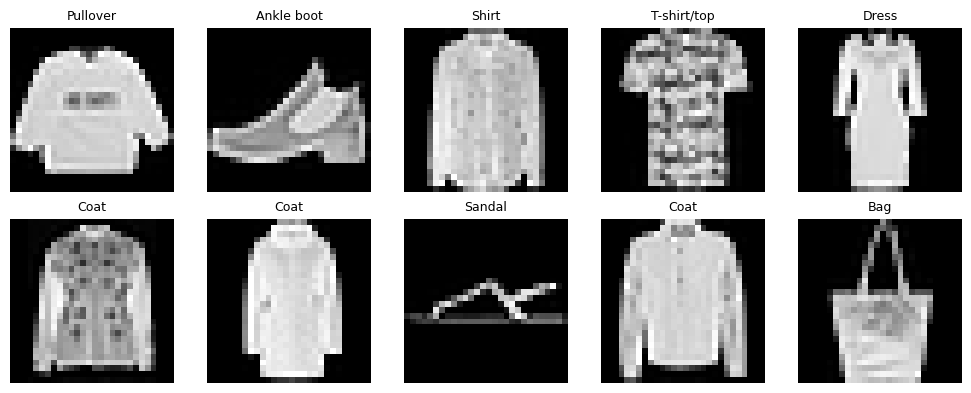

In [5]:
# Visual sanity check: show a few training samples.
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_all[i].squeeze().numpy(), cmap="gray")
    plt.title(CLASS_NAMES[int(y_all[i])], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
def make_train_val_loaders(X, y, validation_ratio=0.15, batch_size=128):
    # Create deterministic train/validation splits and PyTorch DataLoaders.
    n = len(X)
    indices = torch.randperm(n, generator=torch.Generator().manual_seed(SEED))
    val_size = int(n * validation_ratio)
    val_idx = indices[:val_size]
    train_idx = indices[val_size:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    train_loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        TensorDataset(X_val, y_val),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, val_loader


train_loader, val_loader = make_train_val_loaders(
    X_all, y_all, validation_ratio=VALIDATION_RATIO, batch_size=BATCH_SIZE
)

print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches  : 399
Validation batches: 71


## Model definition

In [7]:
class SpiderFashionMNISTNet(nn.Module):
    # MLP architecture matching the model diagram in the task PDF.

    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()

        # Shared trunk: 784 -> 16
        self.input_to_hidden = nn.Linear(28 * 28, 16)

        # Left branch: 16 -> 8 -> 8, then residual add.
        self.left_hidden_1 = nn.Linear(16, 8)
        self.left_hidden_2 = nn.Linear(8, 8)

        # Right branch: 16 -> 12 -> 8
        self.right_hidden_1 = nn.Linear(16, 12)
        self.right_hidden_2 = nn.Linear(12, 8)

        # Concatenate left and right branch outputs: 8 + 8 = 16 -> 10
        self.output_layer = nn.Linear(16, 10)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        shared = self.activation(self.input_to_hidden(x))

        left_1 = self.activation(self.left_hidden_1(shared))
        left_2 = self.activation(self.left_hidden_2(left_1))
        left = left_1 + left_2  # Skip connection add

        right = self.activation(self.right_hidden_1(shared))
        right = self.activation(self.right_hidden_2(right))

        combined = torch.cat([left, right], dim=1)
        logits = self.output_layer(combined)
        return logits


model = SpiderFashionMNISTNet().to(DEVICE)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

SpiderFashionMNISTNet(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (input_to_hidden): Linear(in_features=784, out_features=16, bias=True)
  (left_hidden_1): Linear(in_features=16, out_features=8, bias=True)
  (left_hidden_2): Linear(in_features=8, out_features=8, bias=True)
  (right_hidden_1): Linear(in_features=16, out_features=12, bias=True)
  (right_hidden_2): Linear(in_features=12, out_features=8, bias=True)
  (output_layer): Linear(in_features=16, out_features=10, bias=True)
  (activation): ReLU()
)
Total parameters: 13246
Trainable parameters: 13246


## Training and evaluation utilities

In [8]:
def accuracy_from_logits(logits, labels):
    predictions = logits.argmax(dim=1)
    return (predictions == labels).float().mean().item()


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += batch_size

    return total_loss / total_examples, total_correct / total_examples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += batch_size

    return total_loss / total_examples, total_correct / total_examples

## Train the model

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

best_val_accuracy = 0.0
best_state_dict = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"\nLoaded best validation checkpoint with val_acc={best_val_accuracy:.4f}")

Epoch 01/10 | train_loss=1.0153 train_acc=0.6270 | val_loss=0.6150 val_acc=0.7724
Epoch 02/10 | train_loss=0.5600 train_acc=0.7982 | val_loss=0.5341 val_acc=0.7998
Epoch 03/10 | train_loss=0.4968 train_acc=0.8267 | val_loss=0.4815 val_acc=0.8308
Epoch 04/10 | train_loss=0.4630 train_acc=0.8407 | val_loss=0.4705 val_acc=0.8347
Epoch 05/10 | train_loss=0.4415 train_acc=0.8465 | val_loss=0.4415 val_acc=0.8437
Epoch 06/10 | train_loss=0.4284 train_acc=0.8507 | val_loss=0.4402 val_acc=0.8432
Epoch 07/10 | train_loss=0.4169 train_acc=0.8542 | val_loss=0.4275 val_acc=0.8494
Epoch 08/10 | train_loss=0.4086 train_acc=0.8577 | val_loss=0.4324 val_acc=0.8486
Epoch 09/10 | train_loss=0.4035 train_acc=0.8582 | val_loss=0.4257 val_acc=0.8492
Epoch 10/10 | train_loss=0.3936 train_acc=0.8629 | val_loss=0.4184 val_acc=0.8529

Loaded best validation checkpoint with val_acc=0.8529


## Plot training curves

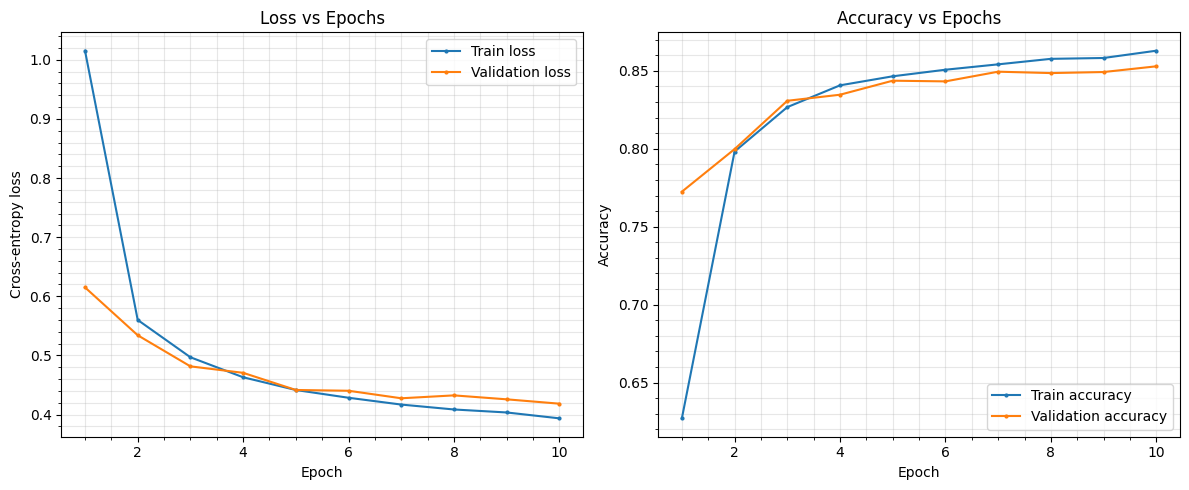

Saved plot to accuracy_loss_plots.png


In [10]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], marker="o", ms = 2, label="Train loss")
plt.plot(epochs, history["val_loss"], marker="o", ms = 2, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Loss vs Epochs")
plt.minorticks_on()  # enable minor ticks on both axes
plt.grid(alpha=0.3, which="both")  # grid for major + minor
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_accuracy"], marker="o", ms = 2, label="Train accuracy")
plt.plot(epochs, history["val_accuracy"], marker="o", ms = 2, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.minorticks_on()  # enable minor ticks on both axes
plt.grid(alpha=0.3, which="both")  # grid for major + minor
plt.legend()

plt.tight_layout()
plt.savefig("accuracy_loss_plots.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved plot to accuracy_loss_plots.png")

## Save model weights using Pickle

In [11]:
weights_path = "spider_fashion_mnist_weights.pkl"
training_metadata = {
    "architecture": "SpiderFashionMNISTNet",
    "class_names": CLASS_NAMES,
    "seed": SEED,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "validation_ratio": VALIDATION_RATIO,
    "best_val_accuracy": float(best_val_accuracy),
    "history": history,
}

with open(weights_path, "wb") as f:
    pickle.dump(
        {
            "model_state_dict": model.state_dict(),
            "metadata": training_metadata,
        },
        f,
    )

print(f"Saved model weights and metadata to {weights_path}")

Saved model weights and metadata to spider_fashion_mnist_weights.pkl


## Generate test predictions and `submission.csv`

In [12]:
@torch.no_grad()
def predict_labels(model, X, batch_size=512, device=DEVICE):
    model.eval()
    loader = DataLoader(TensorDataset(X), batch_size=batch_size, shuffle=False)
    predictions = []

    for (images,) in loader:
        images = images.to(device)
        logits = model(images)
        predictions.append(logits.argmax(dim=1).cpu())

    return torch.cat(predictions).numpy()


test_predictions = predict_labels(model, X_test, batch_size=512, device=DEVICE)

submission = pd.DataFrame({
    "id": np.arange(len(test_predictions)),
    "label": test_predictions.astype(int),
})
submission.to_csv("submission.csv", index=False)

print("Saved submission.csv")
submission.head()

Saved submission.csv


,id,label
0,0,0
1,1,1
2,2,2
3,3,0
4,4,1


In [13]:
# If Kaggle's test CSV contains labels, evaluate on it too.
if y_test is not None:
    test_accuracy = (test_predictions == y_test.numpy()).mean()
    print(f"Test accuracy on provided labelled test CSV: {test_accuracy:.4f}")
else:
    print("The test CSV does not contain labels, so only submission.csv was generated.")

Test accuracy on provided labelled test CSV: 0.8516


## Inspect a few predictions

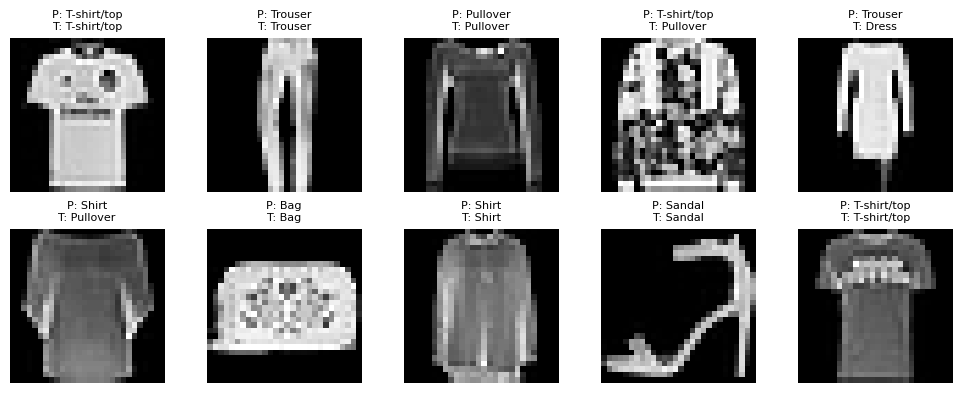

In [14]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].squeeze().numpy(), cmap="gray")
    pred_name = CLASS_NAMES[int(test_predictions[i])]
    if y_test is not None:
        true_name = CLASS_NAMES[int(y_test[i])]
        plt.title(f"P: {pred_name}\nT: {true_name}", fontsize=8)
    else:
        plt.title(f"P: {pred_name}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.savefig("sample_test_predictions.png", dpi=200, bbox_inches="tight")
plt.show()

## Final submission checklist

After running all cells, your Colab working directory should contain:

- `spider_fashion_mnist_weights.pkl`
- `submission.csv`
- `accuracy_loss_plots.png`
- `sample_test_predictions.png`
- This final notebook

For final submission, download the notebook after execution so the printed epoch logs and plots are visible inside the `.ipynb`.